##Inspecting the images

In [1]:
from IPython.display import Image, display


Displaying images: apple.jpg


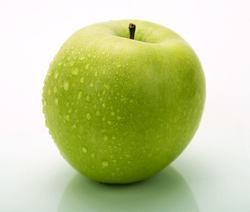


Displaying images: clock.jpg


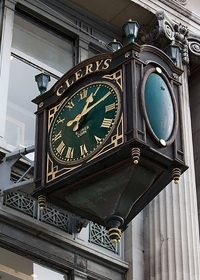


Displaying images: oranges.jpg


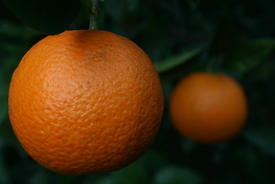


Displaying images: car.jpg


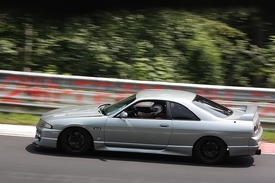

In [2]:
img_files = ['apple.jpg','clock.jpg','oranges.jpg','car.jpg']

for img in img_files:
    print(f"\nDisplaying images: {img}")
    display(Image(filename=f"images/{img}"))

##Creating the detect_and_draw_box function

In [3]:
import os

dir_name = "images_with_boxes"
if not os.path.exists(dir_name):
    os.mkdir(dir_name)

In [4]:
# import sys
# !{sys.executable} -m pip install --upgrade pip setuptools wheel


import sys
!{sys.executable} -m pip install "setuptools<70.0.0"

In [5]:
import sys
!{sys.executable} -m pip install opencv-python-headless

In [6]:
!{sys.executable} -m pip install opencv-python-headless cvlib tensorflow-cpu pillow

In [7]:
import cv2

import cvlib as cv
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 3 <-- Filter out INFO, WARNING, and only show ERROR message
import cvlib as cv

from cvlib.object_detection import draw_bbox 

def detect_and_draw_box(filename,model = 'yolov3-tiny',confidence = 0.5):

    img_filepath = f"images/{filename}"   # Images are stored under the images/ directory
    
    img = cv2.imread(img_filepath)  ## Read the image into a numpy array

    bbox,label,conf = cv.detect_common_objects(img,confidence = confidence, model = model)   # Perform the object detection

    print(f"=================\nImage processeed:{filename}\n")

    for l,c in zip(label,conf):
        print(f"Detected object: {l} with confidece level of {c:.2f}\n")

    output_image = draw_bbox(img,bbox,label,conf)    # Create a new image that includes the bounding boxes

    cv2.imwrite(f'images_with_boxes/{filename}',output_image)   # Save the image in the directory images_with_boxes

    display(Image(f'images_with_boxes/{filename}'))


Image processeed:apple.jpg

Detected object: apple with confidece level of 0.57



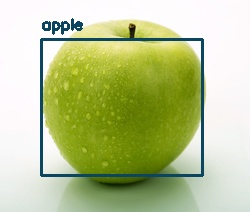

Image processeed:clock.jpg

Detected object: clock with confidece level of 0.97



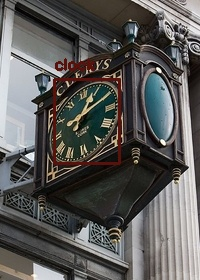

Image processeed:oranges.jpg

Detected object: orange with confidece level of 0.62

Detected object: orange with confidece level of 0.56



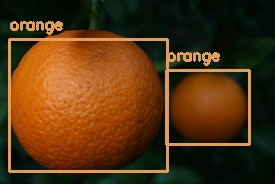

Image processeed:car.jpg

Detected object: car with confidece level of 0.63



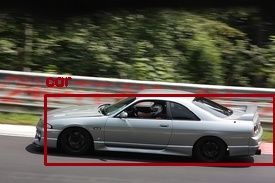

In [8]:
for image in img_files:
    detect_and_draw_box(image)

###Changing the confidence level

Image processeed:fruits.jpg

Detected object: apple with confidece level of 0.58

Detected object: orange with confidece level of 0.53

Detected object: orange with confidece level of 0.52



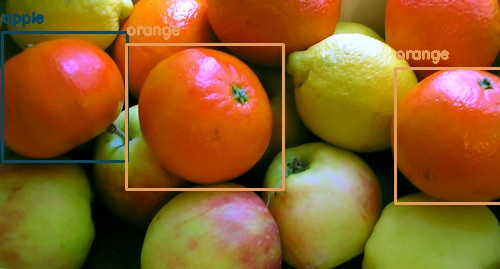

In [9]:
detect_and_draw_box("fruits.jpg")

Image processeed:fruits.jpg

Detected object: apple with confidece level of 0.58

Detected object: orange with confidece level of 0.53

Detected object: orange with confidece level of 0.52

Detected object: apple with confidece level of 0.35

Detected object: orange with confidece level of 0.33

Detected object: apple with confidece level of 0.31



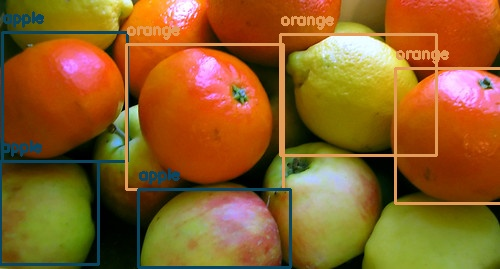

In [10]:
detect_and_draw_box("fruits.jpg",confidence=0.3)

##Deploying the model using FastAPI

###Placing your object detection model in a server

In [11]:
dir_name = "images_uploaded"
if not os.path.exists(dir_name):
    os.mkdir(dir_name)

In [12]:
import sys
!{sys.executable} -m pip install uvicorn fastapi nest_asyncio

In [13]:
import io               #Python’s input/output module.
import uvicorn          #uvicorn is an ASGI server.ASGI = Asynchronous Server Gateway Interface.
import numpy as np
import nest_asyncio     #Allow asyncio loops to nest inside each other
from enum import Enum
from fastapi import FastAPI, UploadFile, File, HTTPException
from fastapi.responses import StreamingResponse

In [14]:
import sys
!{sys.executable} -m pip install python-multipart

In [15]:
app = FastAPI(title="Deploying an ML Model with FastAPI")

class Model(str, Enum):
    yolov3tiny = "yolov3-tiny"
    yolov3 = "yolov3"

@app.get("/")
def home():
    return "Congratulations! Your API is working as expected. Now head over to http://serve/docs"

@app.post("/predict")
def prediction(model:Model,file: UploadFile = File(...)):

    # 1. VALIDATE INPUT FILE

    filename = file.filename
    fileExtension = filename.split(".")[-1] in ("jpg", "jpeg", "png")

    if not fileExtension:
        raise HTTPException(status_code=415, detail="Unsupported file provided.")
    

    # 2. TRANSFORM RAW IMAGE INTO CV2 image

    image_stream = io.BytesIO(file.file.read()) # Read image as a stream of bytes
                                                #. OpenCV cannot read a FastAPI UploadFile directly, so we first convert it to a bytes stream.
    image_stream.seek(0)  # Start the stream from the beginning (position zero)

    file_bytes = np.asarray(bytearray(image_stream.read()), dtype=np.uint8)  # Write the stream of bytes into a numpy array

    image = cv2.imdecode(file_bytes,cv2.IMREAD_COLOR)    # Decode the numpy array as an image


     # 3. RUN OBJECT DETECTION MODEL

    bbox, label, conf = cv.detect_common_objects(image,model=model)

    output_image = draw_bbox(image,bbox,label,conf)

    cv2.imwrite(f'images_uploaded/{filename}',output_image)

    # 4. STREbbAM THE RESPONSE BACK TO THE CLIENT

    file_image = open(f'images_uploaded/{filename}', mode="rb")  # Open the saved image for reading in binary mode

    return StreamingResponse(file_image,media_type="image/jpeg")  # Return the image as a stream specifying media type



  


In [ ]:
import asyncio

nest_asyncio.apply()   # Allows the server to be run in this interactive environment

host = "127.0.0.1"

# uvicorn.run(app, host=host, port=8000, root_path="/serve")

# 2. Setup the configuration
config = uvicorn.Config(app, host=host, port=8000)
server = uvicorn.Server(config)

# 3. Use the EXISTING loop instead of creating a new one
loop = asyncio.get_event_loop()
loop.create_task(server.serve())

<Task pending name='Task-1' coro=<Server.serve() running at c:\Projects\MLOps\LAB1\.venv\Lib\site-packages\uvicorn\server.py:77>>

INFO:     Started server process [38824]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)


INFO:     127.0.0.1:50182 - "GET / HTTP/1.1" 200 OK
INFO:     127.0.0.1:57916 - "POST /predict?model=yolov3-tiny HTTP/1.1" 200 OK
INFO:     127.0.0.1:57917 - "POST /predict?model=yolov3-tiny HTTP/1.1" 200 OK
INFO:     127.0.0.1:57918 - "POST /predict?model=yolov3-tiny HTTP/1.1" 200 OK
INFO:     127.0.0.1:57919 - "POST /predict?model=yolov3-tiny HTTP/1.1" 200 OK
INFO:     127.0.0.1:57920 - "POST /predict?model=yolov3-tiny HTTP/1.1" 200 OK
INFO:     127.0.0.1:61995 - "POST /predict?model=yolov3-tiny HTTP/1.1" 200 OK
